# Temporal Fusion Transformer + Optuna
Modular notebook version generated from `tft_optuna.py`.

This notebook trains the TFT to forecast the forward difference y_i - y_{i+1} (default).

## How to use
1. Run the imports cell.
2. Run each section to define helpers/models.
3. Edit the example run cell at the end with your CSV/columns; add `--optuna` to fine-tune (can be slow).

In [1]:
%matplotlib inline

from __future__ import annotations
import os
import math
import json
import argparse
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

try:
    import optuna
except ImportError:
    optuna = None


C:\Users\santo\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Utilities
Seeding, RMSE helper, numpy conversion, and time-based split helper.

In [2]:
def set_seed(seed: int = 0) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def to_np(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()

def time_split_indices(n: int, train_ratio=0.7, val_ratio=0.15) -> Tuple[int, int]:
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return train_end, val_end


def build_splits_with_scalers(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    train_ratio=0.7,
    val_ratio=0.15,
):
    """
    Apply *existing* fitted scalers to recreate splits (used when loading a saved model).
    """
    n = len(df)
    train_end, val_end = time_split_indices(n, train_ratio=train_ratio, val_ratio=val_ratio)

    X = df[feature_cols].values
    y = df[target_col].values.reshape(-1, 1)

    X_train = x_scaler.transform(X[:train_end])
    X_val = x_scaler.transform(X[train_end:val_end])
    X_test = x_scaler.transform(X[val_end:])

    y_train = y_scaler.transform(y[:train_end])
    y_val = y_scaler.transform(y[train_end:val_end])
    y_test = y_scaler.transform(y[val_end:])

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def persistence_baseline_scores(
    df: pd.DataFrame,
    target_col: str,
    seq_len: int,
    horizon: int,
    split_idx: Dict[str, int],
):
    """
    Naive zero baseline: always predict 0.
    Returns per-split RMSE/MAE plus the series for plotting.
    """
    y = df[target_col].to_numpy()
    naive = np.zeros_like(y, dtype=float)


    train_end, val_end = split_idx["train_end"], split_idx["val_end"]
    n = len(df)
    splits = {
        "train": (0, train_end),
        "val": (train_end, val_end),
        "test": (val_end, n),
    }

    def slice_for_split(start: int, end: int):
        length = max(0, (end - start) - seq_len - horizon + 1)
        idx_start = start + seq_len
        idx_end = idx_start + length
        return slice(idx_start, idx_end)

    metrics = {}
    series = {}
    for name, (s, e) in splits.items():
        idx_slice = slice_for_split(s, e)
        y_true = y[idx_slice]
        y_pred = naive[idx_slice]
        if len(y_true) == 0:
            metrics[name] = {"rmse": float("nan"), "mae": float("nan")}
            series[name] = (np.array([]), np.array([]))
            continue
        metrics[name] = {
            "rmse": rmse(y_true, y_pred),
            "mae": float(mean_absolute_error(y_true, y_pred)),
        }
        series[name] = (y_true, y_pred)
    return metrics, series


def evaluate_splits(
    model: nn.Module,
    loaders: List[DataLoader],
    y_scaler: StandardScaler,
    horizon: int,
    split_names: List[str],
):
    """
    Evaluate model per split and return metrics + (true, pred) series for plotting.
    Uses the first horizon step for reporting/plots.
    """
    model.eval()
    metrics = {}
    series = {}
    for name, loader in zip(split_names, loaders):
        preds, trues = [], []
        for xb, yb in loader:
            xb = xb.to(next(model.parameters()).device)
            yb = yb.to(xb.device).squeeze(-1)
            with torch.no_grad():
                yhat, _ = model(xb)
            ph = yhat[:, 0] if yhat.ndim > 1 else yhat
            th = yb[:, 0] if yb.ndim > 1 else yb
            preds.append(to_np(ph))
            trues.append(to_np(th))
        if not preds:
            metrics[name] = {"rmse": float("nan"), "mae": float("nan")}
            series[name] = (np.array([]), np.array([]))
            continue

        preds_np = np.concatenate(preds).reshape(-1, 1)
        trues_np = np.concatenate(trues).reshape(-1, 1)
        preds_inv = y_scaler.inverse_transform(preds_np).flatten()
        trues_inv = y_scaler.inverse_transform(trues_np).flatten()
        metrics[name] = {
            "rmse": rmse(trues_inv, preds_inv),
            "mae": float(mean_absolute_error(trues_inv, preds_inv)),
        }
        series[name] = (trues_inv, preds_inv)
    return metrics, series


def plot_split_graph(
    df: pd.DataFrame,
    split_idx: Dict[str, int],
    seq_len: int,
    horizon: int,
    model_series: Dict[str, Tuple[np.ndarray, np.ndarray]],
    naive_series: Dict[str, Tuple[np.ndarray, np.ndarray]],
    title: str = "TFT vs Naive vs Actual",
):
    """
    Plot actual vs model vs naive across train/val/test with split markers.
    """
    train_end, val_end = split_idx["train_end"], split_idx["val_end"]
    start_train = seq_len
    start_val = train_end + seq_len
    start_test = val_end + seq_len

    idx_train = df.index[start_train : start_train + len(model_series["train"][0])]
    idx_val = df.index[start_val : start_val + len(model_series["val"][0])]
    idx_test = df.index[start_test : start_test + len(model_series["test"][0])]
    idx_all = np.concatenate([idx_train, idx_val, idx_test])

    true_all = np.concatenate([model_series["train"][0], model_series["val"][0], model_series["test"][0]])
    pred_all = np.concatenate([model_series["train"][1], model_series["val"][1], model_series["test"][1]])
    naive_all = np.concatenate([naive_series["train"][1], naive_series["val"][1], naive_series["test"][1]])

    plt.figure(figsize=(12, 6))
    plt.plot(idx_all, true_all, label="Actual", linewidth=2)
    plt.plot(idx_all, pred_all, label="TFT (model)", alpha=0.8)
    plt.plot(idx_all, naive_all, label="Naive (zero)", alpha=0.8)
    plt.axvline(df.index[train_end - 1], color="gray", linestyle="--", label="Train/Val split")
    plt.axvline(df.index[val_end - 1], color="gray", linestyle=":", label="Val/Test split")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_segmented_graph(
    df: pd.DataFrame,
    split_idx: Dict[str, int],
    seq_len: int,
    horizon: int,
    model_series: Dict[str, Tuple[np.ndarray, np.ndarray]],
    naive_series: Dict[str, Tuple[np.ndarray, np.ndarray]],
    title: str = "Segmented TFT vs Naive vs Actual",
):
    """
    Plot separate panels for train/val/test segments.
    """
    train_end, val_end = split_idx["train_end"], split_idx["val_end"]
    start_train = seq_len
    start_val = train_end + seq_len
    start_test = val_end + seq_len

    segments = [
        ("train", start_train),
        ("val", start_val),
        ("test", start_test),
    ]

    fig, axes = plt.subplots(len(segments), 1, figsize=(12, 10), sharex=False)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    legend_handles = legend_labels = None
    for ax, (name, start_idx) in zip(axes, segments):
        y_true, y_pred = model_series[name]
        naive_pred = naive_series[name][1]
        idx = df.index[start_idx : start_idx + len(y_true)]
        if len(y_true) == 0:
            ax.set_title(f"{name.title()} segment (no data)")
            ax.axis("off")
            continue
        ax.plot(idx, y_true, label="Actual", linewidth=2)
        ax.plot(idx, y_pred, label="TFT (model)", alpha=0.8)
        ax.plot(idx, naive_pred, label="Naive (zero)", alpha=0.8)
        ax.set_title(f"{name.title()} segment")
        ax.grid(alpha=0.3)
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc="upper center", ncol=3)
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


### Dataset: Sliding Windows
Creates (X_seq, y) pairs for sequence forecasting.

In [3]:
class TimeSeriesWindowDataset(Dataset):
    """
    Creates (X_seq, y) pairs:
      X_seq: [seq_len, n_features]
      y:     [horizon]  (or scalar if horizon=1)
    """
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        seq_len: int = 60,
        horizon: int = 1,
    ):
        assert X.ndim == 2
        assert y.ndim in (1, 2)
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.seq_len = int(seq_len)
        self.horizon = int(horizon)

        self.n = len(X)
        self.max_start = self.n - self.seq_len - self.horizon + 1
        if self.max_start <= 0:
            raise ValueError(
                f"Not enough data: n={self.n}, seq_len={self.seq_len}, horizon={self.horizon}"
            )

    def __len__(self) -> int:
        return self.max_start

    def __getitem__(self, idx: int):
        s = idx
        e = idx + self.seq_len
        X_seq = self.X[s:e]  # [seq_len, n_features]
        y_seq = self.y[e : e + self.horizon]  # future horizon
        if y_seq.ndim == 1:
            y_seq = y_seq[:, None]
        return torch.from_numpy(X_seq), torch.from_numpy(y_seq)  # y: [horizon, 1]


### TFT Building Blocks
GLU, GRN, variable selection, attention, and the main `TemporalFusionTransformer` class.

In [4]:
class GLU(nn.Module):
    def __init__(self, d_in: int, d_out: int):
        super().__init__()
        self.fc = nn.Linear(d_in, d_out * 2)

    def forward(self, x):
        a, b = self.fc(x).chunk(2, dim=-1)
        return a * torch.sigmoid(b)

class GatedResidualNetwork(nn.Module):
    """
    TFT GRN: Dense -> ELU -> Dense -> Dropout -> GLU gate + skip + LayerNorm
    """
    def __init__(self, d_model: int, d_hidden: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_hidden)
        self.fc2 = nn.Linear(d_hidden, d_model)
        self.dropout = nn.Dropout(dropout)
        self.glu = GLU(d_model, d_model)
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [..., d_model]
        residual = x
        x = self.fc1(x)
        x = F.elu(x)
        x = self.fc2(x)
        x = self.dropout(x)
        # gated skip
        gated = self.glu(x)
        out = self.ln(gated + residual)
        return out

class VariableSelectionNetwork(nn.Module):
    """
    Continuous-only variable selection:
      - Project each variable to d_model
      - Compute weights via GRN on concatenated inputs
      - Weighted sum of variable embeddings

    Input:
      x: [B, T, n_vars]  (continuous)
    Output:
      v: [B, T, d_model]
      w: [B, T, n_vars]
    """
    def __init__(self, n_vars: int, d_model: int, d_hidden: int, dropout: float):
        super().__init__()
        self.n_vars = n_vars
        self.d_model = d_model
        self.var_proj = nn.ModuleList([nn.Linear(1, d_model) for _ in range(n_vars)])
        self.weight_grn = GatedResidualNetwork(d_model=n_vars * d_model, d_hidden=d_hidden, dropout=dropout)
        self.weight_out = nn.Linear(n_vars * d_model, n_vars)

    def forward(self, x):
        B, T, V = x.shape
        assert V == self.n_vars

        var_embs = []
        for i in range(V):
            xi = x[..., i:i+1]                       # [B,T,1]
            ei = self.var_proj[i](xi)                # [B,T,d_model]
            var_embs.append(ei)
        E = torch.stack(var_embs, dim=-2)            # [B,T,V,d_model]
        flat = E.reshape(B, T, V * self.d_model)     # [B,T,V*d_model]

        h = self.weight_grn(flat)                    # [B,T,V*d_model]
        w = self.weight_out(h)                       # [B,T,V]
        w = torch.softmax(w, dim=-1)

        v = torch.sum(E * w.unsqueeze(-1), dim=-2)   # [B,T,d_model]
        return v, w

class InterpretableMultiHeadAttention(nn.Module):
    """
    A simplified multi-head attention (TFT uses interpretable attention).
    Here we implement standard MHA with residual + layernorm around it.
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x, attn_mask=None):
        # x: [B,T,d_model]
        residual = x
        out, attn = self.mha(x, x, x, attn_mask=attn_mask, need_weights=True)
        out = self.dropout(out)
        out = self.ln(out + residual)
        return out, attn


class TemporalFusionTransformer(nn.Module):
    """
    Practical TFT for next-step regression:
    - Variable Selection (continuous)
    - LSTM encoder
    - GRN + Multi-head attention
    - Position-wise GRN
    - Output head for horizon steps

    This is not a 1:1 reproduction of the original paper’s full static covariate path,
    but it captures the core TFT ideas used in forecasting pipelines.
    """
    def __init__(
        self,
        n_vars: int,
        d_model: int = 64,
        d_hidden: int = 128,
        lstm_layers: int = 2,
        dropout: float = 0.1,
        n_heads: int = 4,
        horizon: int = 1,
    ):
        super().__init__()
        self.n_vars = n_vars
        self.d_model = d_model
        self.horizon = horizon

        self.vsn = VariableSelectionNetwork(n_vars=n_vars, d_model=d_model, d_hidden=d_hidden, dropout=dropout)

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.post_lstm_grn = GatedResidualNetwork(d_model=d_model, d_hidden=d_hidden, dropout=dropout)
        self.attn = InterpretableMultiHeadAttention(d_model=d_model, n_heads=n_heads, dropout=dropout)
        self.post_attn_grn = GatedResidualNetwork(d_model=d_model, d_hidden=d_hidden, dropout=dropout)

        self.out = nn.Linear(d_model, horizon)  # output horizon values

    def forward(self, x):
        """
        x: [B, T, n_vars]
        returns:
          yhat: [B, horizon]
          var_w: [B, T, n_vars] (for interpretability)
        """
        v, var_w = self.vsn(x)                  # [B,T,d_model]
        h, _ = self.lstm(v)                     # [B,T,d_model]
        h = self.post_lstm_grn(h)               # [B,T,d_model]

        # causal-ish mask so attention can't peek forward inside the encoder window
        T = h.size(1)
        causal_mask = torch.triu(torch.ones(T, T, device=h.device, dtype=torch.bool), diagonal=1)

        h_attn, attn_w = self.attn(h, attn_mask=causal_mask)
        h_attn = self.post_attn_grn(h_attn)

        # use last time step representation for next-step forecast
        last = h_attn[:, -1, :]                 # [B,d_model]
        yhat = self.out(last)                   # [B,horizon]
        return yhat, var_w


### Training & Checkpoint Helpers
Loss/metrics loops plus checkpoint save/load.

In [5]:
@dataclass
class TrainConfig:
    seq_len: int = 60
    horizon: int = 1
    batch_size: int = 64
    epochs: int = 30
    lr: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 0

def train_one_epoch(model, loader, optimizer, device, grad_clip: float):
    model.train()
    losses = []
    for xb, yb in loader:
        xb = xb.to(device)                   # [B,T,V]
        yb = yb.to(device)                   # [B,H,1]
        yb = yb.squeeze(-1)                  # [B,H]

        optimizer.zero_grad(set_to_none=True)
        yhat, _ = model(xb)                  # [B,H]
        loss = F.smooth_l1_loss(yhat, yb)    # huber-ish stable loss
        loss.backward()
        if grad_clip and grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else float("nan")

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    losses = []
    preds = []
    trues = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device).squeeze(-1)
        yhat, _ = model(xb)
        loss = F.smooth_l1_loss(yhat, yb)
        losses.append(loss.item())
        preds.append(to_np(yhat))
        trues.append(to_np(yb))
    if not preds:
        return float("nan"), np.array([]), np.array([])
    return float(np.mean(losses)), np.vstack(preds), np.vstack(trues)

def save_checkpoint(path: str, model: nn.Module, meta: Dict, scalers: Optional[Dict[str, StandardScaler]] = None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {"state_dict": model.state_dict(), "meta": meta}
    if scalers is not None:
        payload["scalers"] = scalers
    torch.save(payload, path)

def load_checkpoint(path: str, model: Optional[nn.Module] = None, map_location="cpu"):
    allowed = [StandardScaler]
    load_kwargs = {"map_location": map_location}
    try:
        with torch.serialization.safe_globals(allowed):
            ckpt = torch.load(path, weights_only=False, **load_kwargs)
    except TypeError:
        # torch <2.6 does not support weights_only
        with torch.serialization.safe_globals(allowed):
            ckpt = torch.load(path, **load_kwargs)
    if model is not None:
        model.load_state_dict(ckpt["state_dict"])
    meta = ckpt.get("meta", {})
    scalers = ckpt.get("scalers")
    return meta, scalers


### Data Prep, Baseline, Plotting
Load CSV, scale splits, zero baseline, evaluation helpers, and plotting.

In [6]:

def load_and_prepare(
    csv_path: str,
    time_col: str,
    target_col: str,
    drop_cols: Optional[List[str]] = None,
    predict_diff: bool = True,
) -> Tuple[pd.DataFrame, List[str], str]:
    """
    Load CSV, optionally compute forward difference target (y_i - y_{i+1}),
    and return the cleaned DataFrame, feature columns, and the target column name used.
    """
    df = pd.read_csv(csv_path)
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
        df = df.sort_values(time_col).reset_index(drop=True)

    if drop_cols:
        for c in drop_cols:
            if c in df.columns:
                df = df.drop(columns=[c])

    if predict_diff:
        diff_col = f"{target_col}_diff_next"
        df[diff_col] = df[target_col] - df[target_col].shift(-1)
        df = df.iloc[:-1].reset_index(drop=True)  # remove last NaN from shift
        target_col = diff_col

    # keep only numeric columns + target (time_col can be non-numeric)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in CSV columns.")
    if target_col not in num_cols:
        raise ValueError(f"target_col '{target_col}' must be numeric.")

    feature_cols = [c for c in num_cols if c != target_col]
    if len(feature_cols) < 1:
        raise ValueError("Need at least one numeric feature column besides target.")

    # simple missing handling (forward fill then back fill)
    df[feature_cols + [target_col]] = df[feature_cols + [target_col]].ffill().bfill()

    return df, feature_cols, target_col


def build_splits_and_scalers(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    train_ratio=0.7,
    val_ratio=0.15,
):
    n = len(df)
    train_end, val_end = time_split_indices(n, train_ratio=train_ratio, val_ratio=val_ratio)

    X = df[feature_cols].values
    y = df[target_col].values.reshape(-1, 1)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X[:train_end])
    X_val   = x_scaler.transform(X[train_end:val_end])
    X_test  = x_scaler.transform(X[val_end:])

    y_train = y_scaler.fit_transform(y[:train_end])
    y_val   = y_scaler.transform(y[train_end:val_end])
    y_test  = y_scaler.transform(y[val_end:])

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), x_scaler, y_scaler


### Fine-tune Freeze Modes
Freeze subsets of layers for head/top/all strategies.

In [7]:
def freeze_for_finetune(model: TemporalFusionTransformer, mode: str):
    """
    mode:
      - "head": freeze everything except out layer (fastest)
      - "top":  train attention + post-attn GRN + out
      - "all":  train everything
    """
    for p in model.parameters():
        p.requires_grad = True

    if mode == "all":
        return

    # freeze most
    for p in model.vsn.parameters():
        p.requires_grad = False
    for p in model.lstm.parameters():
        p.requires_grad = False
    for p in model.post_lstm_grn.parameters():
        p.requires_grad = False

    if mode == "head":
        for p in model.attn.parameters():
            p.requires_grad = False
        for p in model.post_attn_grn.parameters():
            p.requires_grad = False

    # out always trainable
    for p in model.out.parameters():
        p.requires_grad = True


### CLI-style Entry Point
`main()` wires everything together; accepts the same arguments as the script version.

In [8]:
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--csv", type=str, required=True, help="Path to CSV")
    ap.add_argument("--time_col", type=str, default="Date")
    ap.add_argument("--target_col", type=str, default="TreasuryYield")
    ap.add_argument("--predict_diff", action="store_true", default=True,
                    help="Predict forward diff y_i - y_{i+1}")
    ap.add_argument("--no_predict_diff", action="store_false", dest="predict_diff",
                    help="Use raw target instead of forward difference")
    ap.add_argument("--drop_cols", type=str, default="", help="Comma-separated columns to drop")
    ap.add_argument("--seq_len", type=int, default=60)
    ap.add_argument("--horizon", type=int, default=1)
    ap.add_argument("--epochs", type=int, default=30)
    ap.add_argument("--batch_size", type=int, default=64)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--weight_decay", type=float, default=1e-4)
    ap.add_argument("--grad_clip", type=float, default=1.0)
    ap.add_argument("--d_model", type=int, default=64)
    ap.add_argument("--d_hidden", type=int, default=128)
    ap.add_argument("--lstm_layers", type=int, default=2)
    ap.add_argument("--dropout", type=float, default=0.1)
    ap.add_argument("--n_heads", type=int, default=4)
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    ap.add_argument("--train_ratio", type=float, default=0.7, help="Train split ratio")
    ap.add_argument("--val_ratio", type=float, default=0.15, help="Validation split ratio")

    ap.add_argument("--save_dir", type=str, default="checkpoints_tft")
    ap.add_argument("--pretrained", type=str, default="", help="Optional path to pretrained checkpoint")
    ap.add_argument("--finetune_mode", type=str, default="top", choices=["head", "top", "all"])
    ap.add_argument("--force_retrain", action="store_true", help="Ignore saved checkpoints and retrain/tune")
    ap.add_argument("--no_plot", action="store_true", help="Skip plotting the split graph")

    ap.add_argument("--optuna", action="store_true", help="Run optuna fine-tuning")
    ap.add_argument("--trials", type=int, default=30)
    ap.add_argument("--optuna_epochs", type=int, default=10)
    args = ap.parse_args()

    set_seed(args.seed)
    args.plot = not args.no_plot

    drop_cols = [c.strip() for c in args.drop_cols.split(',') if c.strip()] or None
    df, feature_cols, target_col = load_and_prepare(args.csv, args.time_col, args.target_col, drop_cols=drop_cols, predict_diff=args.predict_diff)

    n = len(df)
    train_end, val_end = time_split_indices(n, train_ratio=args.train_ratio, val_ratio=args.val_ratio)
    split_idx = {"train_end": train_end, "val_end": val_end}

    (X_train, y_train), (X_val, y_val), (X_test, y_test), x_scaler, y_scaler = \
        build_splits_and_scalers(df, feature_cols, target_col, train_ratio=args.train_ratio, val_ratio=args.val_ratio)

    seq_len = args.seq_len
    horizon = args.horizon

    def make_loader(ds, bs, shuffle=False):
        return DataLoader(ds, batch_size=bs, shuffle=shuffle, drop_last=False, num_workers=0)

    baseline_ckpt = os.path.join(args.save_dir, "tft_best.pt")
    tuned_ckpt = os.path.join(args.save_dir, "tft_finetuned_best.pt")
    target_ckpt = tuned_ckpt if args.optuna else baseline_ckpt

    loaded = False
    meta_loaded: Dict = {}
    scalers_loaded: Optional[Dict[str, StandardScaler]] = None
    if (not args.force_retrain) and Path(target_ckpt).exists():
        ckpt = torch.load(target_ckpt, map_location=args.device)
        meta_loaded = ckpt.get("meta", {})
        scalers_loaded = ckpt.get("scalers")

        seq_len = meta_loaded.get("seq_len", seq_len)
        horizon = meta_loaded.get("horizon", horizon)
        feature_cols = meta_loaded.get("feature_cols", feature_cols)

        if scalers_loaded and scalers_loaded.get("x") is not None and scalers_loaded.get("y") is not None:
            (X_train, y_train), (X_val, y_val), (X_test, y_test) = build_splits_with_scalers(
                df,
                feature_cols,
                target_col,
                scalers_loaded["x"],
                scalers_loaded["y"],
                train_ratio=meta_loaded.get("train_ratio", args.train_ratio),
                val_ratio=meta_loaded.get("val_ratio", args.val_ratio),
            )
            x_scaler, y_scaler = scalers_loaded["x"], scalers_loaded["y"]

        n_vars = len(feature_cols)
        cfg = meta_loaded.get("args", vars(args))
        best_params = meta_loaded.get("optuna_best_params", {})
        model = TemporalFusionTransformer(
            n_vars=n_vars,
            d_model=cfg.get("d_model", args.d_model),
            d_hidden=cfg.get("d_hidden", args.d_hidden),
            lstm_layers=cfg.get("lstm_layers", args.lstm_layers),
            dropout=best_params.get("dropout", cfg.get("dropout", args.dropout)),
            n_heads=cfg.get("n_heads", args.n_heads),
            horizon=horizon,
        ).to(args.device)
        model.load_state_dict(ckpt["state_dict"])
        print(f"Loaded saved model from {target_ckpt}")
        loaded = True
    else:
        n_vars = len(feature_cols)
        model = None

    train_ds = TimeSeriesWindowDataset(X_train, y_train, seq_len=seq_len, horizon=horizon)
    val_ds   = TimeSeriesWindowDataset(X_val,   y_val,   seq_len=seq_len, horizon=horizon)
    test_ds  = TimeSeriesWindowDataset(X_test,  y_test,  seq_len=seq_len, horizon=horizon)

    train_loader = make_loader(train_ds, args.batch_size, shuffle=True)
    val_loader   = make_loader(val_ds, args.batch_size, shuffle=False)
    test_loader  = make_loader(test_ds, args.batch_size, shuffle=False)

    if (not loaded) and (not args.optuna):
        model = TemporalFusionTransformer(
            n_vars=n_vars,
            d_model=args.d_model,
            d_hidden=args.d_hidden,
            lstm_layers=args.lstm_layers,
            dropout=args.dropout,
            n_heads=args.n_heads,
            horizon=horizon,
        ).to(args.device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
        best_val = float('inf')
        best_path = baseline_ckpt

        for ep in range(1, args.epochs + 1):
            tr_loss = train_one_epoch(model, train_loader, optimizer, args.device, args.grad_clip)
            va_loss, va_pred, va_true = eval_epoch(model, val_loader, args.device)

            va_pred_inv = y_scaler.inverse_transform(va_pred)
            va_true_inv = y_scaler.inverse_transform(va_true)
            va_rmse = rmse(va_true_inv, va_pred_inv)
            va_mae = float(mean_absolute_error(va_true_inv, va_pred_inv))

            print(f"[epoch {ep:03d}] train_loss={tr_loss:.5f} val_loss={va_loss:.5f} val_rmse={va_rmse:.5f} val_mae={va_mae:.5f}")

            if va_loss < best_val:
                best_val = va_loss
                meta = {
                    "feature_cols": feature_cols,
                    "target_col": target_col,
                    "seq_len": seq_len,
                    "horizon": horizon,
                    "train_ratio": args.train_ratio,
                    "val_ratio": args.val_ratio,
                    "args": vars(args),
                }
                save_checkpoint(best_path, model, meta, {"x": x_scaler, "y": y_scaler})

        load_checkpoint(best_path, model, map_location=args.device)
        target_ckpt = best_path
        print(f"Saved best checkpoint: {best_path}")
        loaded = True

    if (not loaded) and args.optuna:
        if optuna is None:
            raise RuntimeError("Optuna not installed. pip install optuna")

        default_pretrained = baseline_ckpt
        pretrained_path = args.pretrained.strip() or default_pretrained
        if not os.path.exists(pretrained_path):
            print(f"Pretrained checkpoint not found at '{pretrained_path}'. Training baseline first...")
            tmp_model = TemporalFusionTransformer(
                n_vars=n_vars,
                d_model=args.d_model,
                d_hidden=args.d_hidden,
                lstm_layers=args.lstm_layers,
                dropout=args.dropout,
                n_heads=args.n_heads,
                horizon=horizon,
            ).to(args.device)
            tmp_opt = torch.optim.AdamW(tmp_model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
            best_val = float('inf')
            for ep in range(1, args.epochs + 1):
                tr_loss = train_one_epoch(tmp_model, train_loader, tmp_opt, args.device, args.grad_clip)
                va_loss, _, _ = eval_epoch(tmp_model, val_loader, args.device)
                if va_loss < best_val:
                    best_val = va_loss
                    meta = {
                        "feature_cols": feature_cols,
                        "target_col": target_col,
                        "seq_len": seq_len,
                        "horizon": horizon,
                        "train_ratio": args.train_ratio,
                        "val_ratio": args.val_ratio,
                        "args": vars(args),
                    }
                    save_checkpoint(pretrained_path, tmp_model, meta, {"x": x_scaler, "y": y_scaler})
            print(f"Baseline checkpoint created at {pretrained_path}")

        def objective(trial: "optuna.Trial") -> float:
            ft_lr = trial.suggest_float("lr", 1e-5, 5e-3, log=True)
            ft_wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
            ft_bs = trial.suggest_categorical("batch_size", [32, 64, 128])
            ft_clip = trial.suggest_float("grad_clip", 0.5, 5.0)
            ft_dropout = trial.suggest_float("dropout", 0.0, 0.3)

            train_loader_t = make_loader(train_ds, ft_bs, shuffle=True)
            val_loader_t   = make_loader(val_ds,   ft_bs, shuffle=False)

            model_t = TemporalFusionTransformer(
                n_vars=n_vars,
                d_model=args.d_model,
                d_hidden=args.d_hidden,
                lstm_layers=args.lstm_layers,
                dropout=ft_dropout,
                n_heads=args.n_heads,
                horizon=horizon,
            ).to(args.device)

            load_checkpoint(pretrained_path, model_t, map_location=args.device)
            freeze_for_finetune(model_t, args.finetune_mode)

            params = [p for p in model_t.parameters() if p.requires_grad]
            optimizer = torch.optim.AdamW(params, lr=ft_lr, weight_decay=ft_wd)

            best = float('inf')
            for ep in range(1, args.optuna_epochs + 1):
                tr_loss = train_one_epoch(model_t, train_loader_t, optimizer, args.device, ft_clip)
                va_loss, _, _ = eval_epoch(model_t, val_loader_t, args.device)

                trial.report(va_loss, ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()

                best = min(best, va_loss)

            return best

        pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
        study = optuna.create_study(direction="minimize", pruner=pruner)
        study.optimize(objective, n_trials=args.trials)

        print("\n=== OPTUNA BEST ===")
        print("best_value:", study.best_value)
        print("best_params:", json.dumps(study.best_params, indent=2))

        bp = study.best_params
        final_bs = int(bp["batch_size"])
        final_loader_train = make_loader(train_ds, final_bs, shuffle=True)
        final_loader_val   = make_loader(val_ds,   final_bs, shuffle=False)
        final_loader_test  = make_loader(test_ds,  final_bs, shuffle=False)

        final_model = TemporalFusionTransformer(
            n_vars=n_vars,
            d_model=args.d_model,
            d_hidden=args.d_hidden,
            lstm_layers=args.lstm_layers,
            dropout=float(bp["dropout"]),
            n_heads=args.n_heads,
            horizon=horizon,
        ).to(args.device)

        load_checkpoint(pretrained_path, final_model, map_location=args.device)
        freeze_for_finetune(final_model, args.finetune_mode)

        final_params = [p for p in final_model.parameters() if p.requires_grad]
        final_opt = torch.optim.AdamW(final_params, lr=float(bp["lr"]), weight_decay=float(bp["weight_decay"]))

        best_val = float('inf')
        best_path = tuned_ckpt

        for ep in range(1, args.optuna_epochs + 1):
            tr_loss = train_one_epoch(final_model, final_loader_train, final_opt, args.device, float(bp["grad_clip"]))
            va_loss, va_pred, va_true = eval_epoch(final_model, final_loader_val, args.device)

            va_pred_inv = y_scaler.inverse_transform(va_pred)
            va_true_inv = y_scaler.inverse_transform(va_true)
            va_rmse = rmse(va_true_inv, va_pred_inv)
            va_mae = float(mean_absolute_error(va_true_inv, va_pred_inv))

            print(f"[final ft epoch {ep:03d}] train_loss={tr_loss:.5f} val_loss={va_loss:.5f} val_rmse={va_rmse:.5f} val_mae={va_mae:.5f}")

            if va_loss < best_val:
                best_val = va_loss
                meta = {
                    "feature_cols": feature_cols,
                    "target_col": target_col,
                    "seq_len": seq_len,
                    "horizon": horizon,
                    "finetune_mode": args.finetune_mode,
                    "optuna_best_params": bp,
                    "train_ratio": args.train_ratio,
                    "val_ratio": args.val_ratio,
                    "args": vars(args),
                }
                save_checkpoint(best_path, final_model, meta, {"x": x_scaler, "y": y_scaler})

        load_checkpoint(best_path, final_model, map_location=args.device)
        model = final_model
        target_ckpt = best_path
        print(f"Saved fine-tuned checkpoint: {best_path}")
        loaded = True

    if not loaded:
        raise RuntimeError("Model was neither loaded nor trained. Please check inputs.")

    eval_loaders = [
        make_loader(train_ds, args.batch_size, shuffle=False),
        make_loader(val_ds,   args.batch_size, shuffle=False),
        make_loader(test_ds,  args.batch_size, shuffle=False),
    ]
    split_names = ["train", "val", "test"]
    model_metrics, model_series = evaluate_splits(model, eval_loaders, y_scaler, horizon, split_names)
    naive_metrics, naive_series = persistence_baseline_scores(df, target_col, seq_len, horizon, split_idx)

    print("\n=== Comparison (first-step forecast) ===")
    for name in split_names:
        mm = model_metrics[name]
        nm = naive_metrics[name]
        print(f"{name.title():5s} | TFT RMSE {mm['rmse']:.4f} MAE {mm['mae']:.4f} | Naive RMSE {nm['rmse']:.4f} MAE {nm['mae']:.4f}")

    if args.plot:
        plot_split_graph(df, split_idx, seq_len, horizon, model_series, naive_series, title="TFT vs Naive vs Actual")
        plot_segmented_graph(df, split_idx, seq_len, horizon, model_series, naive_series, title="Segmented TFT vs Naive vs Actual")


### Example: quick run
Adjusted for this dataset; change as needed.

[epoch 001] train_loss=0.36959 val_loss=0.20049 val_rmse=0.03325 val_mae=0.02317
Saved best checkpoint: checkpoints_tft\tft_best.pt



=== Comparison (first-step forecast) ===
Train | TFT RMSE 0.0490 MAE 0.0321 | Naive RMSE 0.0660 MAE 0.0407
Val   | TFT RMSE 0.0333 MAE 0.0232 | Naive RMSE 0.0465 MAE 0.0300
Test  | TFT RMSE 0.0463 MAE 0.0317 | Naive RMSE 0.0630 MAE 0.0388


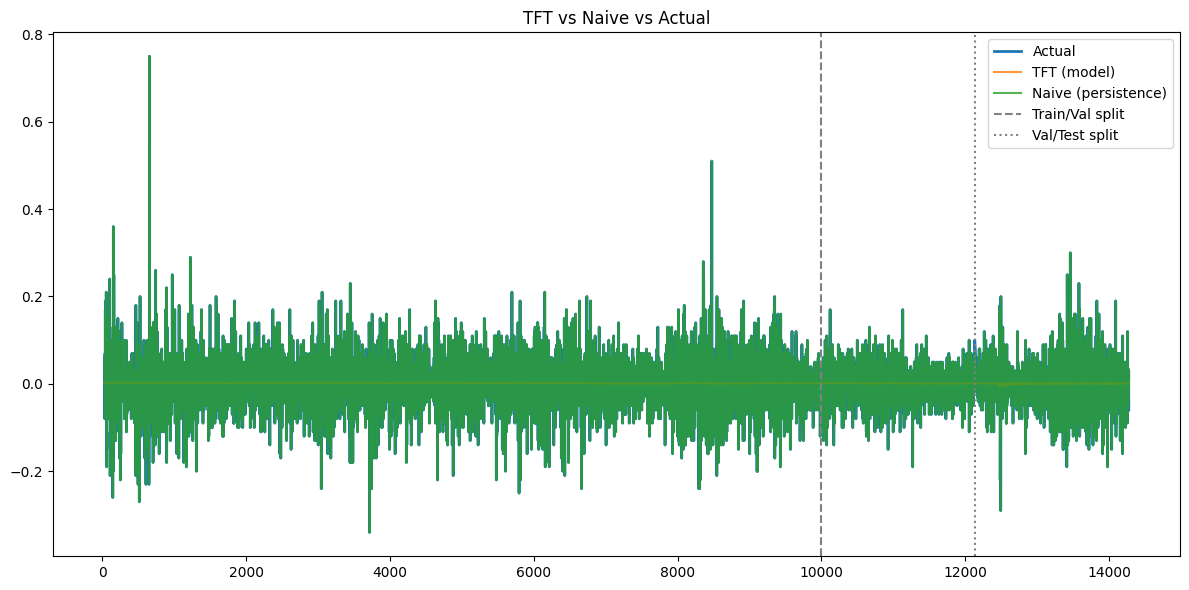

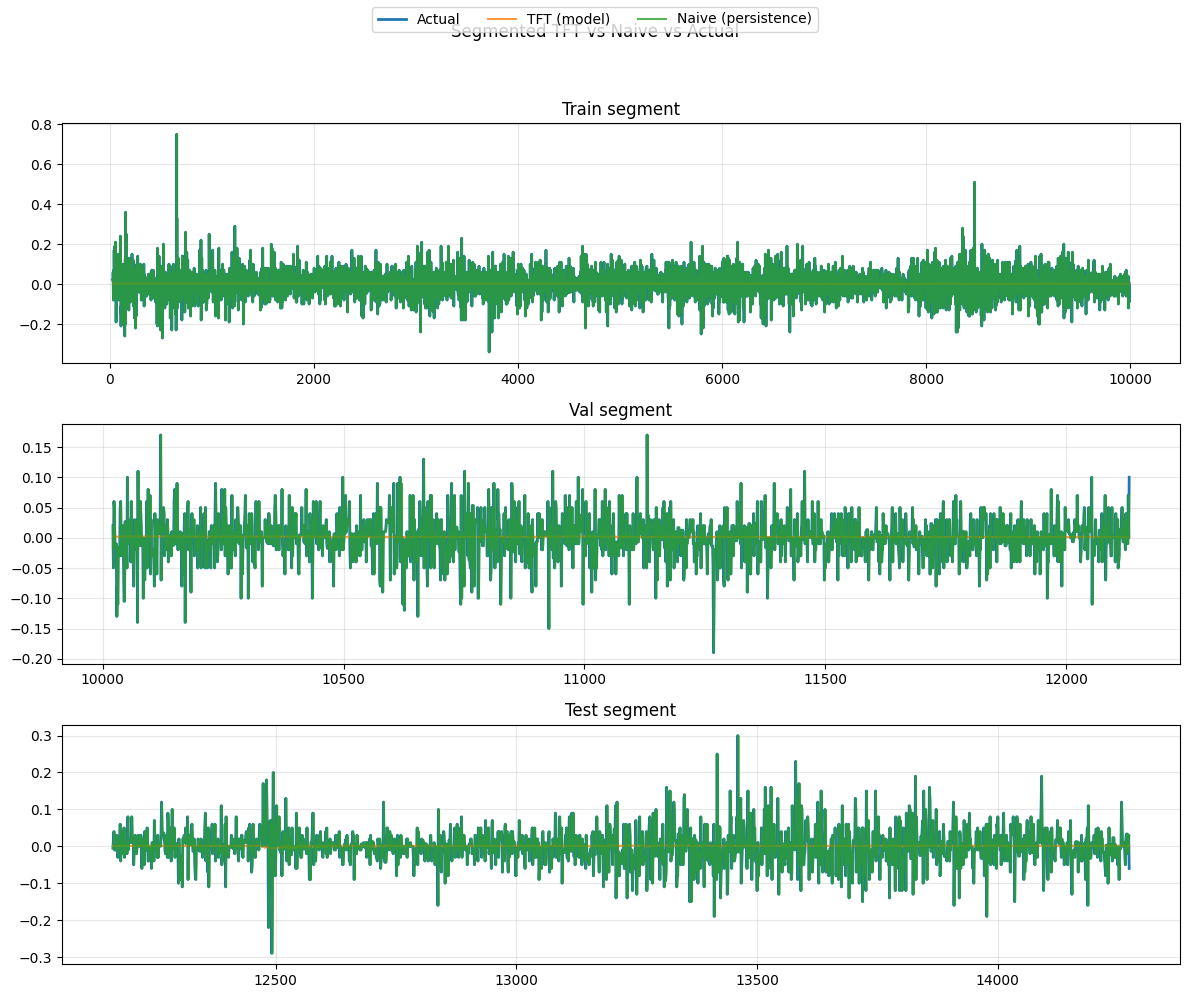

In [9]:

import sys
# Quick CPU-friendly run; adjust as needed
sys.argv = [
    'notebook',
    '--csv', 'new_proj_data.csv',
    '--time_col', 'date',
    '--target_col', 'TreasuryYield',
    '--seq_len', '30',
    '--epochs', '1',
    '--batch_size', '128',
    '--force_retrain',
    '--predict_diff',
]
main()
